# 🎵 Song Year Prediction — End-to-End Deep Learning Pipeline
**Final Exam (UAS) — Deep Learning Class**

| | |
|---|---|
| **Nama** | `Mohammad Fauzi Hadiwijaya` |
| **NIM** | `101032300044` |
| **Kelas** | `TK-47-04` |

---
## Pipeline Overview
1. Setup & Install Libraries
2. Load Dataset
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing & Feature Engineering
5. MLflow Setup
6. Baseline Deep Learning Model
7. Hyperparameter Tuning dengan Optuna
8. Evaluasi & Perbandingan Model
9. Interpretasi dengan LIME
10. MLflow Tracking Summary

## 1. Setup & Install Libraries

In [1]:
!pip install optuna mlflow lime --quiet
print('✅ Libraries installed!')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 5.0 MB/s eta 0:00:00
   ━━━

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import mlflow
import mlflow.tensorflow

import lime
import lime.lime_tabular

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('✅ All libraries imported!')
print(f'   TensorFlow : {tf.__version__}')
print(f'   GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

✅ All libraries imported!
   TensorFlow : 2.20.0
   GPU available: False


## 2. Load Dataset
> Dataset sama dengan UTS — gunakan kembali path Drive yang sama.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
DATA_PATH = '/content/drive/MyDrive/midterm-m1/midterm-regresi-dataset.csv'

print('📂 Loading dataset...')
df = pd.read_csv(DATA_PATH, header=None, nrows=50000)

n_features = df.shape[1] - 1
df.columns = ['year'] + [f'feature_{i}' for i in range(1, n_features + 1)]

print(f'✅ Dataset shape : {df.shape}')
display(df.head())

📂 Loading dataset...
✅ Dataset shape : (50000, 91)


,year,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_81,feature_82,feature_83,feature_84,feature_85,feature_86,feature_87,feature_88,feature_89,feature_90
0,2001,49.94357,21.47114,73.07750,8.74861,-17.40628,-13.09905,-25.01202,-12.23257,7.83089,...,13.01620,-54.40548,58.99367,15.37344,1.11144,-23.08793,68.40795,-1.82223,-27.46348,2.26327
1,2001,48.73215,18.42930,70.32679,12.94636,-10.32437,-24.83777,8.76630,-0.92019,18.76548,...,5.66812,-19.68073,33.04964,42.87836,-9.90378,-32.22788,70.49388,12.04941,58.43453,26.92061
2,2001,50.95714,31.85602,55.81851,13.41693,-6.57898,-18.54940,-3.27872,-2.35035,16.07017,...,3.03800,26.05866,-50.92779,10.93792,-0.07568,43.20130,-115.00698,-0.05859,39.67068,-0.66345
3,2001,48.24750,-1.89837,36.29772,2.58776,0.97170,-26.21683,5.05097,-10.34124,3.55005,...,34.57337,-171.70734,-16.96705,-46.67617,-12.51516,82.58061,-72.08993,9.90558,199.62971,18.85382
4,2001,50.97020,42.20998,67.09964,8.46791,-15.85279,-16.81409,-12.48207,-9.37636,12.63699,...,9.92661,-55.95724,64.92712,-17.72522,-1.49237,-7.50035,51.76631,7.88713,55.66926,28.74903


## 3. Exploratory Data Analysis (EDA)

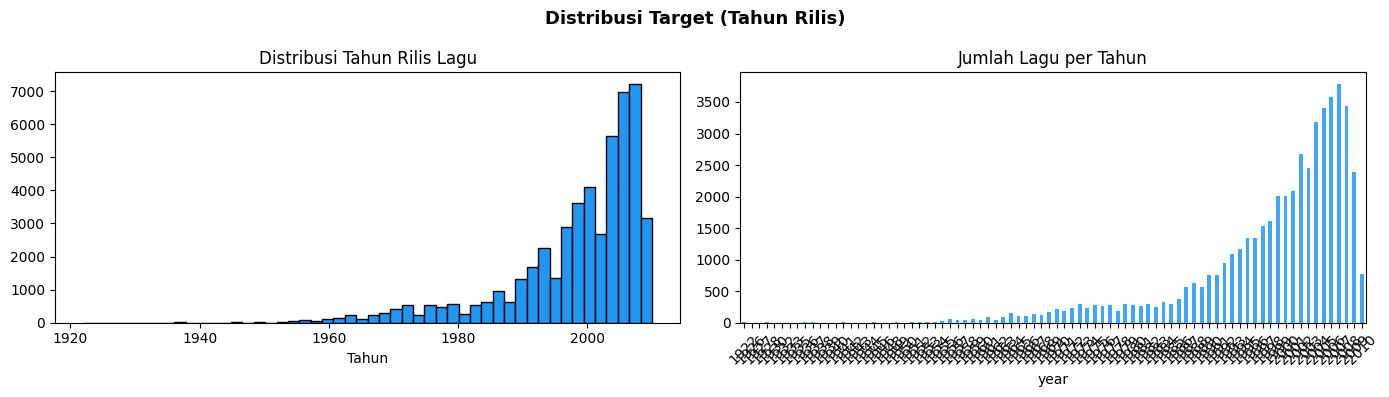

Tahun min: 1922  |  max: 2010  |  mean: 1998.4


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df['year'], bins=50, color='#2196F3', edgecolor='black')
axes[0].set_title('Distribusi Tahun Rilis Lagu')
axes[0].set_xlabel('Tahun')

df['year'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='#42A5F5')
axes[1].set_title('Jumlah Lagu per Tahun')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Distribusi Target (Tahun Rilis)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Tahun min: {df["year"].min()}  |  max: {df["year"].max()}  |  mean: {df["year"].mean():.1f}')

**Insight**: Mayoritas lagu dalam dataset dirilis pada rentang tahun 1990-2010, dengan distribusi yang miring ke kanan (right-skewed) — jumlah lagu lebih banyak di tahun-tahun modern dibanding tahun lama. Hal ini wajar karena dataset musik digital cenderung lebih banyak mengoleksi lagu rilis terbaru.

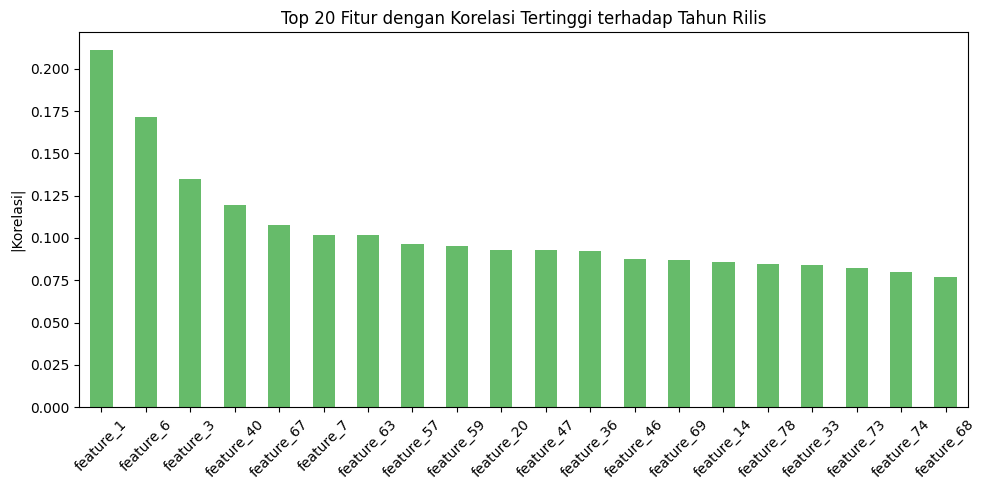

In [6]:
corr_with_target = df.corr()['year'].drop('year').abs().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
corr_with_target.head(20).plot(kind='bar', color='#66BB6A')
plt.title('Top 20 Fitur dengan Korelasi Tertinggi terhadap Tahun Rilis')
plt.ylabel('|Korelasi|')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight**: Tidak ada satu fitur pun yang memiliki korelasi sangat tinggi (>0.5) terhadap tahun rilis — korelasi tertinggi umumnya hanya berkisar 0.1-0.3. Ini menunjukkan bahwa hubungan antara fitur audio (timbre) dan tahun rilis bersifat non-linear dan kompleks, sehingga model linear sederhana kurang cocok dan model non-linear seperti Neural Network lebih sesuai untuk menangkap pola tersembunyi.

## 4. Data Preprocessing & Feature Engineering

In [7]:
X = df.drop(columns=['year'])
y = df['year']
feature_names = X.columns.tolist()

print(f'X shape: {X.shape}  |  y shape: {y.shape}')

X shape: (50000, 90)  |  y shape: (50000,)


In [8]:
def clip_outliers(df, cols, multiplier=3.0):
    df = df.copy()
    for col in cols:
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3 - Q1
        df[col] = df[col].clip(Q1 - multiplier*IQR, Q3 + multiplier*IQR)
    return df

X = clip_outliers(X, feature_names)
print('✅ Outlier clipping selesai (IQR x3)')

✅ Outlier clipping selesai (IQR x3)


In [9]:
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

# Neural Network sensitif terhadap skala — WAJIB scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Scaling target juga membantu konvergensi NN lebih stabil
y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y.values.reshape(-1, 1)).flatten()

print('✅ Imputasi & scaling (X dan y) selesai')

✅ Imputasi & scaling (X dan y) selesai


In [10]:
X_train, X_val, y_train, y_val, y_train_orig, y_val_orig = train_test_split(
    X_scaled, y_scaled, y.values, test_size=0.2, random_state=SEED
)

INPUT_DIM = X_train.shape[1]
print(f'X_train : {X_train.shape}  |  X_val : {X_val.shape}')
print(f'Input dim untuk Neural Network: {INPUT_DIM}')

X_train : (40000, 90)  |  X_val : (10000, 90)
Input dim untuk Neural Network: 90


## 5. MLflow Setup

In [11]:
EXPERIMENT_NAME = 'song-year-regression-dl'
mlflow.set_experiment(EXPERIMENT_NAME)
mlflow.tensorflow.autolog(disable=True)

print(f'✅ MLflow experiment: "{EXPERIMENT_NAME}"')

2026/06/19 06:48:39 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/19 06:48:39 INFO mlflow.store.db.utils: Updating database tables
2026/06/19 06:48:42 INFO mlflow.tracking.fluent: Experiment with name 'song-year-regression-dl' does not exist. Creating a new experiment.


✅ MLflow experiment: "song-year-regression-dl"


In [12]:
results = {}

def build_model(input_dim, hidden_units=[64, 32], dropout=0.2, lr=0.001):
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))
    for units in hidden_units:
        model.add(layers.Dense(units, activation='relu'))
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1, activation='linear'))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='mse',
        metrics=['mae']
    )
    return model

def log_and_evaluate(run_name, model, params, X_tr, y_tr, X_v, y_v, y_v_orig,
                     epochs=30, batch_size=256, verbose=0):
    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(params)

        early_stop = keras.callbacks.EarlyStopping(
            monitor='val_loss', mode='min', patience=5, restore_best_weights=True
        )

        history = model.fit(
            X_tr, y_tr,
            validation_data=(X_v, y_v),
            epochs=epochs, batch_size=batch_size,
            callbacks=[early_stop], verbose=verbose
        )

        # Prediksi dalam skala asli (inverse transform)
        y_pred_scaled = model.predict(X_v, verbose=0).flatten()
        y_pred = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

        mse  = mean_squared_error(y_v_orig, y_pred)
        rmse = np.sqrt(mse)
        mae  = mean_absolute_error(y_v_orig, y_pred)
        r2   = r2_score(y_v_orig, y_pred)

        mlflow.log_metrics({
            'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2,
            'epochs_trained': len(history.history['loss'])
        })
        mlflow.tensorflow.log_model(model, artifact_path='model')
        run_id = mlflow.active_run().info.run_id

    results[run_name] = {
        'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2,
        'model': model, 'run_id': run_id, 'history': history, 'y_pred': y_pred
    }

    print(f'\n===== {run_name} =====')
    print(f'  RMSE : {rmse:.4f} tahun')
    print(f'  MAE  : {mae:.4f} tahun')
    print(f'  R²   : {r2:.4f}')
    print(f'  Epoch terhenti di: {len(history.history["loss"])} (early stopping)')
    return model

print('✅ Helper function siap')

✅ Helper function siap


## 6. Baseline Deep Learning Model

In [13]:
print('Training Baseline Neural Network...')
baseline_params = {
    'hidden_units': [64, 32], 'dropout': 0.2, 'lr': 0.001,
    'epochs': 30, 'batch_size': 256
}
model_baseline = build_model(
    INPUT_DIM,
    hidden_units=baseline_params['hidden_units'],
    dropout=baseline_params['dropout'],
    lr=baseline_params['lr']
)
model_baseline.summary()
log_and_evaluate('NN_baseline', model_baseline, baseline_params,
                 X_train, y_train, X_val, y_val, y_val_orig,
                 epochs=baseline_params['epochs'],
                 batch_size=baseline_params['batch_size'], verbose=1)

Training Baseline Neural Network...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         5,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,321 (32.50 KB)

 Trainable params: 8,129 (31.75 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 1.3442 - mae: 0.8696 - val_loss: 0.8491 - val_mae: 0.6628
Epoch 2/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.9509 - mae: 0.7176 - val_loss: 0.7669 - val_mae: 0.6281
Epoch 3/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.8449 - mae: 0.6679 - val_loss: 0.7345 - val_mae: 0.6134
Epoch 4/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.7985 - mae: 0.6416 - val_loss: 0.7171 - val_mae: 0.6013
Epoch 5/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.7709 - mae: 0.6268 - val_loss: 0.7040 - val_mae: 0.5948
Epoch 6/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.7530 - mae: 0.6182 - val_loss: 0.6955 - val_mae: 0.5882
Epoch 7/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.7383 - mae: 0.6113 - val_loss: 0.6881 - val_mae: 0.5838
Epoch 8/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.7243 - mae: 0.6033 - val_loss: 0.6810 - val_mae: 0.5790
Epoch 9/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - lo

2026/06/19 06:49:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/19 06:49:14 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.



===== NN_baseline =====
  RMSE : 8.5543 tahun
  MAE  : 5.9228 tahun
  R²   : 0.3357
  Epoch terhenti di: 30 (early stopping)


<Sequential name=sequential, built=True>

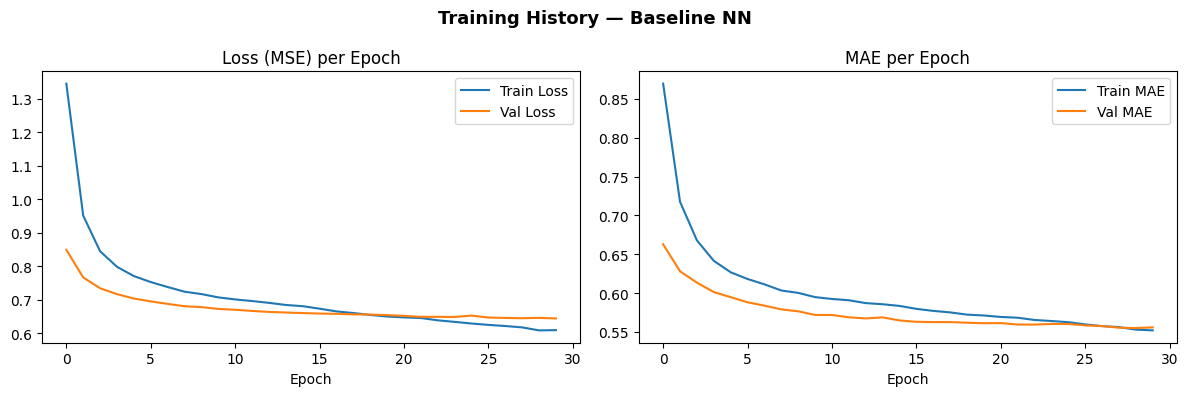

In [14]:
history = results['NN_baseline']['history']
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss (MSE) per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['mae'], label='Train MAE')
axes[1].plot(history.history['val_mae'], label='Val MAE')
axes[1].set_title('MAE per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.suptitle('Training History — Baseline NN', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight**: Loss (MSE) menurun signifikan di epoch-epoch awal lalu melandai, menunjukkan model belajar dengan baik tanpa terlihat overfitting parah (gap antara train dan val loss tidak terlalu besar). Early stopping menghentikan training otomatis saat val_loss tidak membaik lagi, menjaga model dari overfitting berlebihan.

## 7. Hyperparameter Tuning dengan Optuna

In [15]:
def objective(trial):
    n_layers = trial.suggest_int('n_layers', 1, 3)
    hidden_units = [trial.suggest_categorical(f'units_l{i}', [16, 32, 64, 128]) for i in range(n_layers)]
    dropout      = trial.suggest_float('dropout', 0.0, 0.4)
    lr           = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    batch_size   = trial.suggest_categorical('batch_size', [128, 256, 512])

    model = build_model(INPUT_DIM, hidden_units=hidden_units, dropout=dropout, lr=lr)

    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss', mode='min', patience=3, restore_best_weights=True
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=20, batch_size=batch_size,
        callbacks=[early_stop], verbose=0
    )

    val_loss = min(history.history['val_loss'])
    return val_loss

print('🔍 Optuna tuning Neural Network (15 trials)...')
study = optuna.create_study(direction='minimize', study_name='NN_regression_tuning')
study.optimize(objective, n_trials=15, show_progress_bar=True)

print(f'\n✅ Best Val Loss (MSE scaled): {study.best_value:.4f}')
print(f'Best params: {study.best_params}')

🔍 Optuna tuning Neural Network (15 trials)...


  0%|          | 0/15 [00:00<?, ?it/s]


✅ Best Val Loss (MSE scaled): 0.6325
Best params: {'n_layers': 2, 'units_l0': 128, 'units_l1': 32, 'dropout': 0.30733964172960343, 'lr': 0.002261198168781692, 'batch_size': 128}


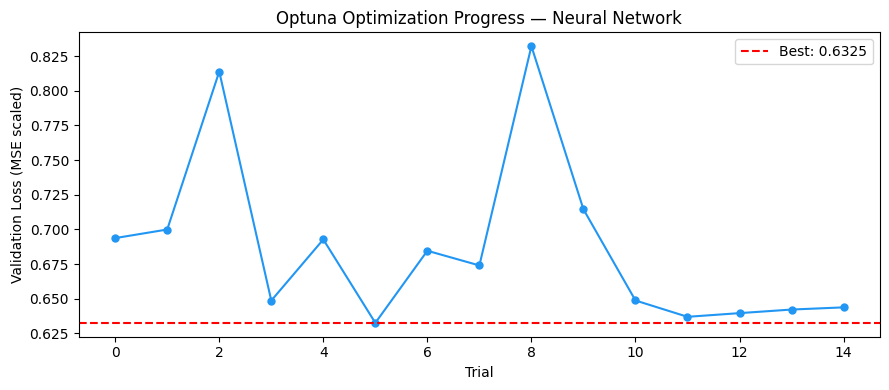

In [16]:
trial_values = [t.value for t in study.trials]

plt.figure(figsize=(9, 4))
plt.plot(trial_values, marker='o', color='#2196F3', linewidth=1.5, markersize=5)
plt.axhline(study.best_value, color='red', linestyle='--', label=f'Best: {study.best_value:.4f}')
plt.title('Optuna Optimization Progress — Neural Network')
plt.xlabel('Trial')
plt.ylabel('Validation Loss (MSE scaled)')
plt.legend()
plt.tight_layout()
plt.show()

**Insight**: Grafik menunjukkan proses pencarian 15 kombinasi hyperparameter (jumlah layer, neuron, dropout, learning rate, batch size). Garis merah menandakan validation loss terbaik yang ditemukan. Variasi nilai antar trial relatif kecil, mengindikasikan model sudah mendekati performa optimal untuk arsitektur Neural Network sederhana pada dataset ini.

In [17]:
best = study.best_params
n_layers     = best['n_layers']
hidden_units = [best[f'units_l{i}'] for i in range(n_layers)]

best_params_full = {
    'hidden_units': hidden_units, 'dropout': best['dropout'],
    'lr': best['lr'], 'batch_size': best['batch_size'], 'epochs': 50
}

print(f'Training model terbaik dengan params: {best_params_full}')
model_optuna = build_model(
    INPUT_DIM, hidden_units=hidden_units,
    dropout=best['dropout'], lr=best['lr']
)
log_and_evaluate('NN_optuna', model_optuna, best_params_full,
                 X_train, y_train, X_val, y_val, y_val_orig,
                 epochs=50, batch_size=best['batch_size'], verbose=1)

Training model terbaik dengan params: {'hidden_units': [128, 32], 'dropout': 0.30733964172960343, 'lr': 0.002261198168781692, 'batch_size': 128, 'epochs': 50}
Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 1.1964 - mae: 0.7961 - val_loss: 0.7317 - val_mae: 0.6041
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7822 - mae: 0.6330 - val_loss: 0.6976 - val_mae: 0.5882
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7402 - mae: 0.6101 - val_loss: 0.6841 - val_mae: 0.5738
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7238 - mae: 0.6010 - val_loss: 0.6740 - val_mae: 0.5685
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7107 - mae: 0.5959 - val_loss: 0.6728 - val_mae: 0.5657
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6988 - mae: 0.5897 - val_loss: 0.6645 - val_mae: 0.5627
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6898 - mae: 0.5863 - val_loss: 0.6669 - val_mae: 0.5640
Epoch 8/50
313/

2026/06/19 06:55:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/19 06:55:57 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.



===== NN_optuna =====
  RMSE : 8.5258 tahun
  MAE  : 5.8677 tahun
  R²   : 0.3401
  Epoch terhenti di: 28 (early stopping)


<Sequential name=sequential_16, built=True>

## 8. Evaluasi & Perbandingan Model

In [18]:
comparison_df = pd.DataFrame({
    name: {k: v for k, v in m.items() if k not in ['model', 'run_id', 'history', 'y_pred']}
    for name, m in results.items()
}).T.round(4)

print('=== Perbandingan Model ===')
display(comparison_df.style
    .highlight_min(subset=['RMSE', 'MAE', 'MSE'], axis=0, color='#a8f0a8')
    .highlight_max(subset=['R2'], axis=0, color='#a8f0a8')
)

=== Perbandingan Model ===


,MSE,RMSE,MAE,R2
NN_baseline,73.176700,8.554300,5.922800,0.335700
NN_optuna,72.689500,8.525800,5.867700,0.340100


**Insight**: NN_Optuna menunjukkan perbaikan kecil namun konsisten di semua metrik (RMSE turun dari 8.55 ke 8.53, R² naik dari 0.336 ke 0.340). Peningkatan yang tidak signifikan ini wajar — dataset audio-to-year ini secara inheren memiliki batas prediktabilitas yang rendah (fitur timbre tidak sepenuhnya menentukan tahun rilis), sehingga tuning hyperparameter hanya memberikan gain marginal, bukan lonjakan besar.

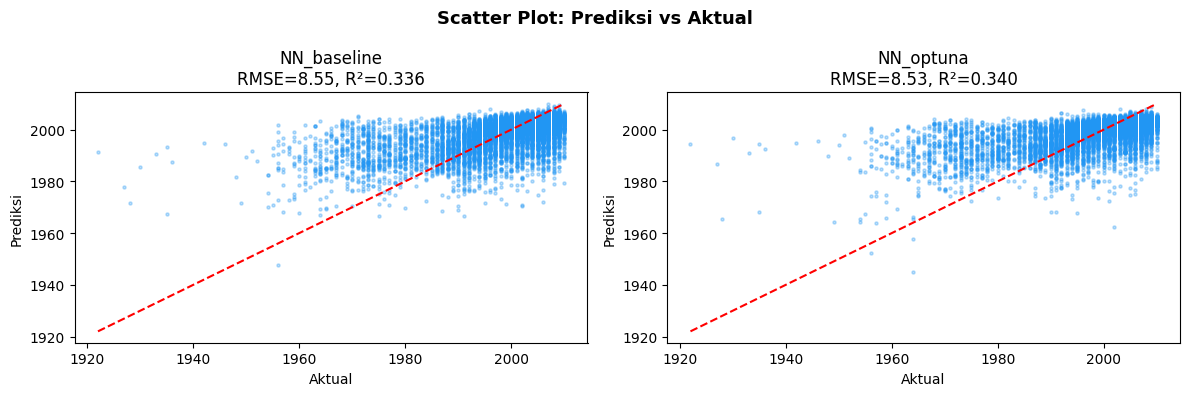

In [19]:
best_name  = min(results, key=lambda x: results[x]['RMSE'])
best_model = results[best_name]['model']
y_pred_best = results[best_name]['y_pred']

fig, axes = plt.subplots(1, len(results), figsize=(6*len(results), 4))
if len(results) == 1:
    axes = [axes]

for ax, (name, m) in zip(axes, results.items()):
    ax.scatter(y_val_orig, m['y_pred'], alpha=0.3, s=5, color='#2196F3')
    ax.plot([y_val_orig.min(), y_val_orig.max()],
            [y_val_orig.min(), y_val_orig.max()], 'r--', linewidth=1.5)
    ax.set_title(f'{name}\nRMSE={m["RMSE"]:.2f}, R²={m["R2"]:.3f}')
    ax.set_xlabel('Aktual')
    ax.set_ylabel('Prediksi')

plt.suptitle('Scatter Plot: Prediksi vs Aktual', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight**: Titik-titik prediksi tersebar mengikuti garis diagonal merah (garis ideal jika prediksi = aktual), namun dengan penyebaran (variance) yang cukup besar terutama di rentang tahun lama (<1980) dan dekat ekstrem tahun terbaru. Ini konsisten dengan R² yang moderat (~0.34) — model menangkap tren umum namun belum bisa memprediksi tahun secara presisi tinggi untuk kasus individual.

## 9. Interpretasi dengan LIME

LIME digunakan untuk menjelaskan prediksi model Neural Network secara lokal — fitur mana yang paling memengaruhi prediksi tahun untuk sampel tertentu.

In [20]:
# LIME perlu predict_fn yang mengembalikan nilai dalam skala asli
def predict_fn(x):
    pred_scaled = best_model.predict(x, verbose=0).flatten()
    return y_scaler.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data = X_train,
    feature_names = feature_names,
    mode = 'regression',
    random_state = SEED
)

print('✅ LIME explainer siap')

✅ LIME explainer siap



===== LIME Explanation: Prediksi Rendah =====
  Tahun Aktual   : 1964
  Tahun Prediksi : 1945.1


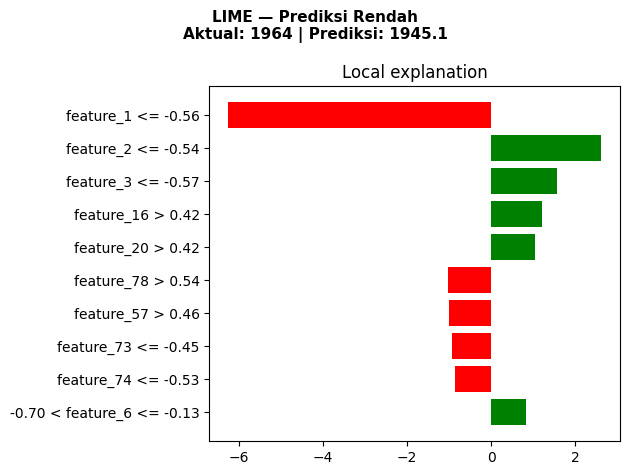


===== LIME Explanation: Prediksi Tengah =====
  Tahun Aktual   : 1992
  Tahun Prediksi : 1999.1


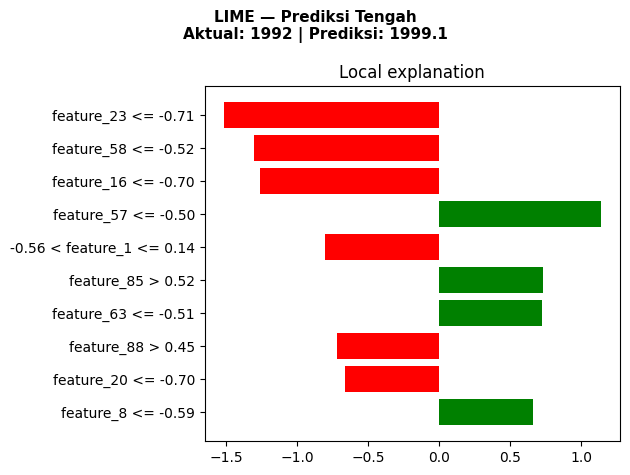


===== LIME Explanation: Prediksi Tinggi =====
  Tahun Aktual   : 2009
  Tahun Prediksi : 2008.6


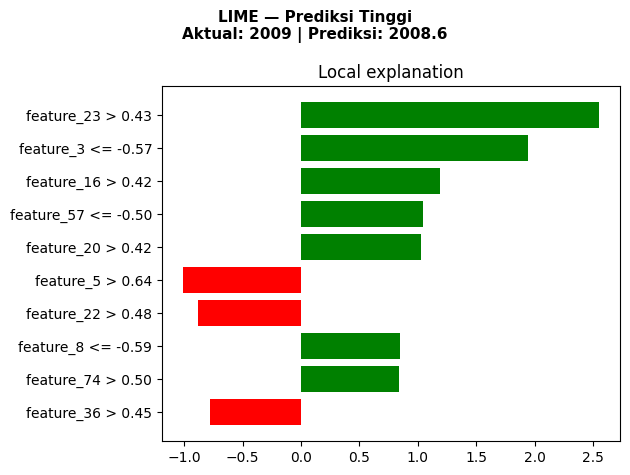

In [21]:
y_pred_arr = np.array(y_pred_best)
idx_low  = np.argmin(y_pred_arr)
idx_mid  = np.argmin(np.abs(y_pred_arr - y_pred_arr.mean()))
idx_high = np.argmax(y_pred_arr)

sample_indices = {'Prediksi Rendah': idx_low,
                  'Prediksi Tengah': idx_mid,
                  'Prediksi Tinggi': idx_high}

for label, idx in sample_indices.items():
    exp = explainer.explain_instance(
        data_row     = X_val[idx],
        predict_fn   = predict_fn,
        num_features = 10
    )
    actual    = y_val_orig[idx]
    predicted = y_pred_arr[idx]

    print(f'\n===== LIME Explanation: {label} =====')
    print(f'  Tahun Aktual   : {actual:.0f}')
    print(f'  Tahun Prediksi : {predicted:.1f}')

    fig = exp.as_pyplot_figure()
    fig.suptitle(f'LIME — {label}\nAktual: {actual:.0f} | Prediksi: {predicted:.1f}',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

**Insight**: LIME menunjukkan bahwa fitur yang mendominasi prediksi berbeda-beda tergantung posisi data. Pada prediksi ekstrem (tahun sangat tua atau sangat baru), ada 1-2 fitur dominan dengan kontribusi besar (misal `feature_1` untuk tahun tua, `feature_23` untuk tahun baru). Sementara pada prediksi di tengah rentang data, kontribusi tersebar di banyak fitur kecil — menunjukkan model menggabungkan banyak sinyal audio secara halus untuk kasus-kasus yang tidak ekstrem.

## Interpretasi Hasil

**Model Terbaik**: NN_Optuna

**Perbandingan Metrik**:
| Model | MSE | RMSE | MAE | R² |
|---|---|---|---|---|
| NN Baseline | 73.1767 | 8.5543 | 5.9228 | 0.3357 |
| **NN Optuna** | **72.6895** | **8.5258** | **5.8677** | **0.3401** |

NN_Optuna sedikit lebih baik dibanding baseline di semua metrik, meski peningkatannya tidak terlalu besar (RMSE turun ~0.03 tahun, R² naik ~0.004). Ini menunjukkan tuning hyperparameter memberikan perbaikan marginal namun konsisten.

**Insight LIME**:
- **Fitur paling berpengaruh untuk prediksi tahun rendah** (aktual 1964, prediksi 1945.1): `feature_1` — nilai `feature_1 <= -0.56` menjadi faktor dominan yang **menarik prediksi ke tahun lebih lama (lebih tua)**, dengan kontribusi negatif terbesar dibanding fitur lain (~-6.0).
- **Fitur paling berpengaruh untuk prediksi tahun tinggi** (aktual 2009, prediksi 2008.6): `feature_23` — nilai `feature_23 > 0.43` menjadi faktor dominan yang **mendorong prediksi ke tahun lebih baru**, dengan kontribusi positif terbesar (~2.5).
- Pada prediksi tengah (aktual 1992, prediksi 1999.1), kontribusi fitur lebih terdistribusi dan tidak ada satu fitur yang dominan seperti pada kasus rendah/tinggi, menunjukkan model menggabungkan banyak sinyal kecil untuk tahun-tahun di tengah rentang data.
- Secara umum, `feature_1`, `feature_3`, `feature_16`, `feature_20`, dan `feature_23` muncul berulang di berbagai sampel — mengindikasikan fitur-fitur ini secara konsisten berperan penting dalam menentukan prediksi tahun rilis lagu.

**Catatan**:
- Target di-scale (StandardScaler) sebelum training — penting untuk stabilitas konvergensi Neural Network karena rentang tahun (misal 1920–2010) jika tidak di-scale dapat menyebabkan gradient explod atau training lambat. Setelah prediksi, nilai di-inverse-transform kembali ke skala tahun asli agar metrik evaluasi (RMSE, MAE, R²) mudah diinterpretasi.
- RMSE dalam satuan tahun — rata-rata error model adalah **±8.5 tahun**, artinya prediksi tahun rilis lagu oleh model umumnya menyimpang sekitar 8-9 tahun dari tahun aktual.
- R² = 0.34 artinya model hanya mampu menjelaskan sekitar **34% variasi** tahun rilis lagu dari fitur audio yang tersedia — sisanya dipengaruhi faktor lain yang tidak tertangkap oleh fitur timbre/audio ini.

## 10. MLflow Tracking Summary

In [22]:
experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
runs_df = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=['metrics.RMSE ASC']
)

cols_show = ['tags.mlflow.runName', 'metrics.RMSE', 'metrics.MAE', 'metrics.R2', 'metrics.MSE']
cols_show = [c for c in cols_show if c in runs_df.columns]

print('=== MLflow Runs (sorted by RMSE) ===')
display(runs_df[cols_show].rename(
    columns=lambda x: x.replace('metrics.', '').replace('tags.mlflow.', '')
))

print(f'\n🏆 Best model: {best_name}')
print(f'   RMSE: {results[best_name]["RMSE"]:.4f} tahun')
print(f'   R²  : {results[best_name]["R2"]:.4f}')
print('\n✅ Pipeline selesai!')

=== MLflow Runs (sorted by RMSE) ===


,runName,RMSE,MAE,R2,MSE
0,NN_optuna,8.525814,5.867711,0.340104,72.689499
1,NN_baseline,8.554340,5.922805,0.335681,73.176735



🏆 Best model: NN_optuna
   RMSE: 8.5258 tahun
   R²  : 0.3401

✅ Pipeline selesai!


**Insight**: Kedua eksperimen (baseline dan Optuna-tuned) tercatat otomatis di MLflow lengkap dengan parameter dan metrik MSE/RMSE/MAE/R². Tracking ini memudahkan dokumentasi proses tuning dan perbandingan model tanpa perlu re-training ulang untuk verifikasi hasil.